## Student performance Analysis

Manually created a datset of some students.
Apply some statistical method to explore students performance based on their academic records.

In [90]:
import pandas as pd 
import matplotlib.pyplot as plt

In [91]:
try:
    df = pd.read_csv("student_performance_dataset.csv")
    display("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The file 'student_performance_dataset.csv' was not found.")

'Dataset loaded successfully.'

In [92]:
df.head(10)

,Student Name,Age,Gender,Course,Attendance,Assignment Score,Midterm Score,Final Score
0,Ali,20,Male,Artificial Intelligence,90.0,85.0,78.0,88.0
1,Ahmed,21,Male,Data Science,82.0,72.0,68.0,74.0
2,Sara,19,Female,Cyber Security,95.0,92.0,90.0,NaN
3,Fatima,22,Female,Software Engineering,88.0,84.0,81.0,86.0
4,Usman,20,Male,Artificial Intelligence,70.0,65.0,60.0,66.0
5,Ayesha,21,Female,Data Science,98.0,95.0,91.0,97.0
6,Hamza,23,Male,Cyber Security,76.0,71.0,69.0,73.0
7,Hina,20,Female,Software Engineering,64.0,58.0,55.0,NaN
8,Bilal,22,Male,Artificial Intelligence,91.0,87.0,83.0,89.0
9,Maryam,19,Female,Data Science,85.0,NaN,77.0,82.0


In [93]:
# Display basic information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student Name      30 non-null     str    
 1   Age               30 non-null     int64  
 2   Gender            30 non-null     str    
 3   Course            30 non-null     str    
 4   Attendance        29 non-null     float64
 5   Assignment Score  28 non-null     float64
 6   Midterm Score     29 non-null     float64
 7   Final Score       27 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.0 KB


In [94]:
df.describe()

,Age,Attendance,Assignment Score,Midterm Score,Final Score
count,30.000000,29.000000,28.000000,29.000000,27.000000
mean,20.833333,82.862069,77.964286,75.206897,79.962963
std,1.315251,11.293880,13.312434,13.289038,13.019162
min,19.000000,58.000000,50.000000,47.000000,49.000000
25%,20.000000,74.000000,68.500000,65.000000,71.000000
50%,21.000000,85.000000,80.500000,77.000000,82.000000
75%,22.000000,92.000000,89.250000,87.000000,89.500000
max,23.000000,99.000000,98.000000,96.000000,99.000000


In [95]:
df.shape

(30, 8)

In [96]:
df.columns

Index(['Student Name', 'Age', 'Gender', 'Course', 'Attendance',
       'Assignment Score', 'Midterm Score', 'Final Score'],
      dtype='str')

In [97]:
# Rename the columns for better readability

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [98]:
df.columns

Index(['student_name', 'age', 'gender', 'course', 'attendance',
       'assignment_score', 'midterm_score', 'final_score'],
      dtype='str')

In [99]:
df.isnull().sum()

student_name        0
age                 0
gender              0
course              0
attendance          1
assignment_score    2
midterm_score       1
final_score         3
dtype: int64

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_name      30 non-null     str    
 1   age               30 non-null     int64  
 2   gender            30 non-null     str    
 3   course            30 non-null     str    
 4   attendance        29 non-null     float64
 5   assignment_score  28 non-null     float64
 6   midterm_score     29 non-null     float64
 7   final_score       27 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.0 KB


In [101]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

C:\Users\Hp\AppData\Local\Temp\ipykernel_19280\1430469304.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


In [102]:
def fill_numerical_missing_values(df, numerical_columns):
    """
    Fill missing values in numerical columns using the median of each column."""
    
    df = df.copy()  # Create a copy of the DataFrame to avoid modifying the original
    
    for column in numerical_columns:
        df[column] = df[column].fillna(df[column].median())

    return df

## Even Better (Automatic Column Detection)
**Instead of manually writing column names, let Pandas detect them.**

In [103]:
numerical_columns = df.select_dtypes(include="number").columns

categorical_columns = df.select_dtypes(include="object").columns

C:\Users\Hp\AppData\Local\Temp\ipykernel_19280\4230003749.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [104]:
def fill_categorical_missing_values(df, categorical_columns):
    """
    Fill missing values in categorical columns using the mode of each column."""
    
    df = df.copy()  # Create a copy of the DataFrame to avoid modifying the original
    
    for column in categorical_columns:
        df[column] = df[column].fillna(df[column].mode()[0])

    return df

In [105]:
display(df[numerical_columns])

,age,attendance,assignment_score,midterm_score,final_score
0,20,90.0,85.0,78.0,88.0
1,21,82.0,72.0,68.0,74.0
2,19,95.0,92.0,90.0,NaN
3,22,88.0,84.0,81.0,86.0
4,20,70.0,65.0,60.0,66.0
5,21,98.0,95.0,91.0,97.0
6,23,76.0,71.0,69.0,73.0
7,20,64.0,58.0,55.0,NaN
8,22,91.0,87.0,83.0,89.0
9,19,85.0,NaN,77.0,82.0


In [106]:
display(df[categorical_columns])

,student_name,gender,course
0,Ali,Male,Artificial Intelligence
1,Ahmed,Male,Data Science
2,Sara,Female,Cyber Security
3,Fatima,Female,Software Engineering
4,Usman,Male,Artificial Intelligence
5,Ayesha,Female,Data Science
6,Hamza,Male,Cyber Security
7,Hina,Female,Software Engineering
8,Bilal,Male,Artificial Intelligence
9,Maryam,Female,Data Science


In [107]:
df = fill_numerical_missing_values(df, numerical_columns)

df = fill_categorical_missing_values(df, categorical_columns)

In [108]:
# verify the missing values have been filled or not 
display(df.isnull().sum())

student_name        0
age                 0
gender              0
course              0
attendance          0
assignment_score    0
midterm_score       0
final_score         0
dtype: int64

In [109]:
display(df["assignment_score"].mean())
display(df["midterm_score"].mean())
display(df["final_score"].mean())

np.float64(78.13333333333334)

np.float64(75.26666666666667)

np.float64(80.16666666666667)

In [110]:
display(f"Highest Assignment Score : {df['assignment_score'].max()}")
display(f"Highest Midterm Score : {df['midterm_score'].max()}")
display(f"Highest Final Score : {df['final_score'].max()}")

'Highest Assignment Score : 98.0'

'Highest Midterm Score : 96.0'

'Highest Final Score : 99.0'

In [111]:
display(f"Lowest Assignment Score : {df['assignment_score'].min()}")
display(f"Lowest Midterm Score : {df['midterm_score'].min()}")
display(f"Lowest Final Score : {df['final_score'].min()}")

'Lowest Assignment Score : 50.0'

'Lowest Midterm Score : 47.0'

'Lowest Final Score : 49.0'

In [112]:
low_attendance = df[df["attendance"] < 75]

display(f"Number of students with attendance below 75%: {len(low_attendance)}")

'Number of students with attendance below 75%: 8'

In [113]:
at_risk = df[
    (df["final_score"] < 50) & (df["attendance"] < 75)
]

display(f"Number of students at risk of failing: {len(at_risk)}")

'Number of students at risk of failing: 1'

In [114]:
df.columns

Index(['student_name', 'age', 'gender', 'course', 'attendance',
       'assignment_score', 'midterm_score', 'final_score'],
      dtype='str')

In [115]:
display(df["course"])

0     Artificial Intelligence
1                Data Science
2              Cyber Security
3        Software Engineering
4     Artificial Intelligence
5                Data Science
6              Cyber Security
7        Software Engineering
8     Artificial Intelligence
9                Data Science
10             Cyber Security
11       Software Engineering
12    Artificial Intelligence
13               Data Science
14             Cyber Security
15       Software Engineering
16    Artificial Intelligence
17               Data Science
18             Cyber Security
19       Software Engineering
20    Artificial Intelligence
21               Data Science
22             Cyber Security
23       Software Engineering
24    Artificial Intelligence
25               Data Science
26             Cyber Security
27       Software Engineering
28    Artificial Intelligence
29               Data Science
Name: course, dtype: str

In [116]:
course_average = df.groupby("course")["final_score"].mean().reset_index().rename(columns={"final_score": "average_final_score"})

course_average

,course,average_final_score
0,Artificial Intelligence,68.375000
1,Cyber Security,78.714286
2,Data Science,84.000000
3,Software Engineering,90.714286


In [117]:
# Relationship between attendance and final score
df[["attendance", "final_score"]].corr()

,attendance,final_score
attendance,1.000000,0.862021
final_score,0.862021,1.000000


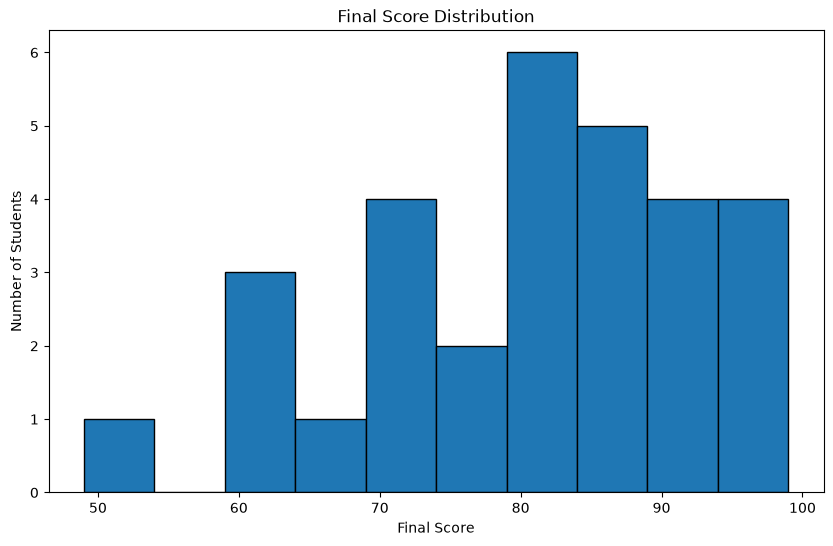

In [118]:
# Visulizations Chart 1: Histogram of final scores

plt.figure(figsize=(10, 6))
plt.hist(df["final_score"], bins=10, edgecolor='black')

plt.title("Final Score Distribution")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

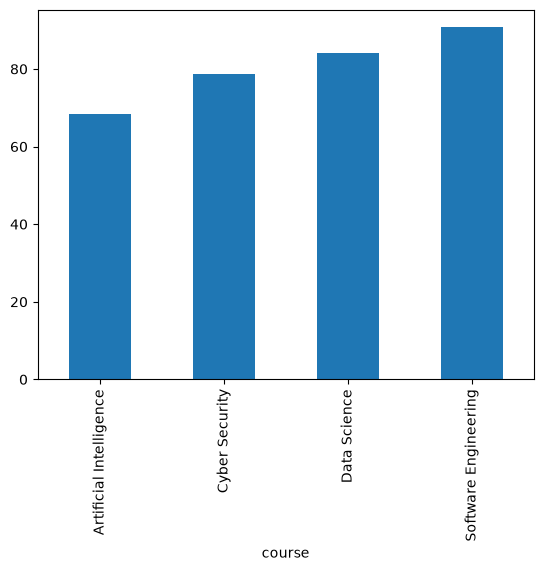

In [119]:
# Bar Chart 2: Average final score by course
course_average.plot(kind="bar", x="course", y="average_final_score", legend=False)
plt.show()

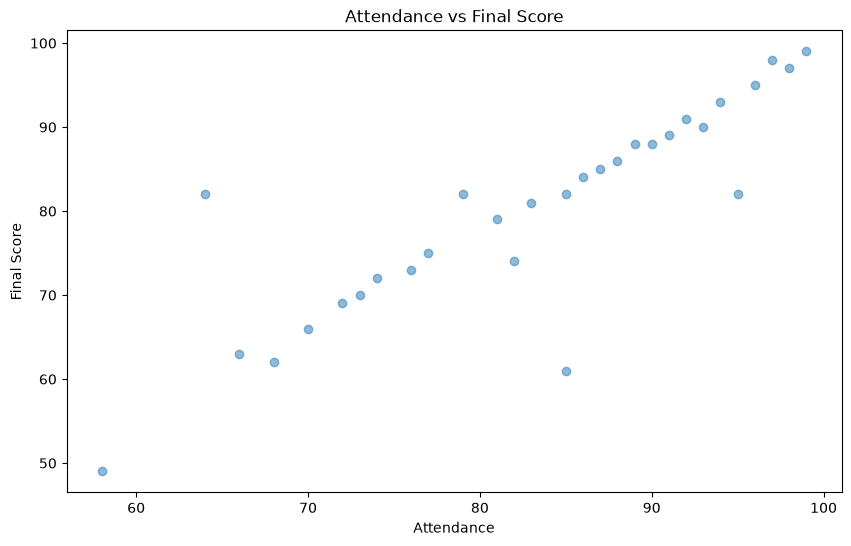

In [120]:
# Scatter Plot 3: Attendance vs Final Score
plt.figure(figsize=(10, 6))
plt.scatter(df["attendance"], df["final_score"], alpha=0.5)
plt.title("Attendance vs Final Score")
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.show()